# Combined Stage A × Stage B evaluation

This notebook composes the two-stage spike-pricing model and evaluates it end-to-end on a held-out year.

- **Stage A (classifier)**: P(spike) — the best Houston-only Stage 1 model from `outputs/session7/` (logistic, `l1_balanced`).
- **Stage B (regressor)**: E[log(SPP) | spike] — the best Houston-only Stage 2 model from `outputs/stage2/houston/` (Random Forest, `depth=10, leaf=5`).

**Combined predictions** (two gating strategies):
- **Hard-gated**: if `P(spike) >= τ`, predict `exp(stage_b_pred)`, else fall back to the training-set mean of non-spike hours. The threshold `τ` is the F1-maximizing threshold from Stage A's pre-test predictions.
- **Soft-gated**: `P(spike) · exp(stage_b_pred) + (1 − P(spike)) · mean_non_spike` — a probability-weighted blend of the two regimes.

**Held-out window**: 2025-04-12 → 2026-04-11 (last 12 months in the dataset, matching the recency analysis test window).

**Baselines (against the combined predictions)**:
- **Mean**: training-set mean SPP, applied to every test hour.
- **24h persistence**: SPP at `t − 24h` predicts SPP at `t`.

**Metrics**: MAE, RMSE, and MAE on the top decile of *actual* test-window SPP — i.e., how well do we predict the very largest hours, where the operational cost of being wrong is highest.

## A note on leakage

The saved Stage 1 and Stage 2 models in `models/*.pkl` were each refit on *all* available data at the end of their training scripts, including the 2025-04-12 → 2026-04-11 window. Evaluating them directly on that window would be in-sample.

To get a clean holdout test, this notebook **loads the saved models only to extract their hyperparameter choices**, then **retrains identical configurations on data strictly before 2025-04-12**. That keeps the comparison honest: we evaluate the same models the user would deploy in production (after refitting on full data), but on data they have not seen.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_recall_curve

In [2]:
PROJECT_ROOT = Path('/Users/raetng/Documents/UChicago/ADA/priv_project_raetng')

# Scope: Houston-only. To repeat for multi-hub, point DATA_PATH at the merged
# parquet without the location filter and load the *_multihub saved models.
LOCATION = 'HB_HOUSTON'
SPIKE_THRESHOLD = 100.0
TEST_START = pd.Timestamp('2025-04-12 00:00:00')
TEST_END   = pd.Timestamp('2026-04-11 23:00:00')

STAGE_A_PATH = PROJECT_ROOT / 'models' / 'logistic_best.pkl'          # Stage 1 winner (Houston)
STAGE_B_PATH = PROJECT_ROOT / 'models' / 'stage2_rf_best_houston.pkl' # Stage 2 winner (Houston)
DATA_PATH    = PROJECT_ROOT / 'data' / 'processed' / 'ercot_merged_dataset.parquet'

print(f'Stage A model: {STAGE_A_PATH.name}')
print(f'Stage B model: {STAGE_B_PATH.name}')
print(f'Test window:   {TEST_START.date()} -> {TEST_END.date()}')

Stage A model: logistic_best.pkl
Stage B model: stage2_rf_best_houston.pkl
Test window:   2025-04-12 -> 2026-04-11


## Load and prepare the data

Filter to HB_HOUSTON, build the binary spike target and log-SPP target, and split into pre-test (training) and test partitions.

In [3]:
df = pd.read_parquet(DATA_PATH)
df = df[df['Location'] == LOCATION].sort_values('datetime').reset_index(drop=True)

df['is_spike'] = (df['SPP'] > SPIKE_THRESHOLD).astype('int8')
df['log_spp'] = np.log(df['SPP'])
for c in ('is_weekend', 'is_holiday'):
    df[c] = df[c].astype('int8')

pre  = df[df['datetime'] <  TEST_START].copy().reset_index(drop=True)
test = df[(df['datetime'] >= TEST_START) & (df['datetime'] <= TEST_END)].copy().reset_index(drop=True)

print(f'pre-test:  {pre["datetime"].min()} -> {pre["datetime"].max()}  n={len(pre):,}  spike_rate={pre["is_spike"].mean():.4f}')
print(f'test:      {test["datetime"].min()} -> {test["datetime"].max()}  n={len(test):,}  spike_rate={test["is_spike"].mean():.4f}')
print(f'\ntest SPP summary:')
print(test['SPP'].describe(percentiles=[.5, .9, .95, .99]).round(2))

pre-test:  2019-01-01 00:00:00 -> 2025-04-11 23:00:00  n=55,031  spike_rate=0.0484
test:      2025-04-12 00:00:00 -> 2026-04-11 23:00:00  n=8,760  spike_rate=0.0210

test SPP summary:
count    8760.00
mean       35.98
std        55.61
min        -0.13
50%        27.76
90%        55.11
95%        70.57
99%       153.96
max      1704.92
Name: SPP, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Feature list

Same 16 features Stage 1 and Stage 2 were trained on — 9 weather + 1 fuel + 6 calendar.

In [4]:
WEATHER  = ['temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
            'dewpoint_2m', 'cloud_cover', 'wind_speed_10m', 'wind_speed_100m',
            'shortwave_radiation', 'direct_normal_irradiance']
FUEL     = ['gas_price_henry_hub']
CALENDAR = ['hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday']
FEATURES = WEATHER + FUEL + CALENDAR
print(f'{len(FEATURES)} features')

16 features


## Stage A retraining on pre-test data

Load the saved Stage A model to extract its hyperparameter dict, then refit `LogisticRegression(**params)` on pre-test data only. Same `StandardScaler` discipline as `train_logistic.py`.

In [5]:
stage_a_saved = load(STAGE_A_PATH)
print(f'Saved Stage A variant: {stage_a_saved["variant"]}')
print(f'Saved Stage A params:  {stage_a_saved["params"]}')

X_pre = pre[FEATURES]
y_pre = pre['is_spike'].astype(int)

scaler_a = StandardScaler()
X_pre_s  = scaler_a.fit_transform(X_pre)

stage_a = LogisticRegression(max_iter=2000, random_state=42, **stage_a_saved['params'])
stage_a.fit(X_pre_s, y_pre)
print(f'Stage A refit on {len(X_pre):,} pre-test rows.')

Saved Stage A variant: l1_balanced
Saved Stage A params:  {'penalty': 'l1', 'C': 1.0, 'solver': 'liblinear', 'class_weight': 'balanced'}


Stage A refit on 55,031 pre-test rows.


### F1-optimal threshold (set on pre-test predictions, not on test set)

The hard-gating threshold is chosen on pre-test data to maximize F1, so no test-set information leaks in. This mirrors the threshold-selection logic in `src/evaluation.py:evaluate_classifier`.

In [6]:
proba_pre = stage_a.predict_proba(X_pre_s)[:, 1]
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_pre, proba_pre)
f1_curve = np.where(
    (prec_arr[:-1] + rec_arr[:-1]) > 0,
    2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1]),
    0.0,
)
best_idx = int(np.argmax(f1_curve))
threshold = float(thr_arr[best_idx])
print(f'F1-optimal threshold on pre-test: {threshold:.4f}')
print(f'  precision={prec_arr[best_idx]:.3f}  recall={rec_arr[best_idx]:.3f}  F1={f1_curve[best_idx]:.3f}')

F1-optimal threshold on pre-test: 0.8364
  precision=0.449  recall=0.564  F1=0.500


In [7]:
# Stage A predictions on the test window
X_test_s = scaler_a.transform(test[FEATURES])
test['p_spike'] = stage_a.predict_proba(X_test_s)[:, 1]
test['stage_a_hard'] = (test['p_spike'] >= threshold).astype(int)

print(f'mean P(spike) on test:        {test["p_spike"].mean():.4f}')
print(f'P(spike) percentiles:         50%={test["p_spike"].quantile(.50):.3f}  '
      f'90%={test["p_spike"].quantile(.90):.3f}  '
      f'99%={test["p_spike"].quantile(.99):.3f}')
print(f'actual spike rate on test:    {test["is_spike"].mean():.4f}')
print(f'hard-gated positive rate:     {test["stage_a_hard"].mean():.4f}')

mean P(spike) on test:        0.2378
P(spike) percentiles:         50%=0.130  90%=0.645  99%=0.999
actual spike rate on test:    0.0210
hard-gated positive rate:     0.0371


## Stage B retraining on pre-test spike subset

Stage B is trained only on hours where the actual SPP exceeds the spike threshold. Load the saved model's hyperparameter dict and refit `RandomForestRegressor(**params)` on the pre-test spike subset.

In [8]:
stage_b_saved = load(STAGE_B_PATH)
print(f'Saved Stage B variant: {stage_b_saved["variant"]}')
print(f'Saved Stage B params:  {stage_b_saved["params"]}')

spike_pre = pre[pre['is_spike'] == 1].reset_index(drop=True)
X_spike_pre = spike_pre[FEATURES]
y_spike_pre = spike_pre['log_spp']

stage_b = RandomForestRegressor(**stage_b_saved['params'])
stage_b.fit(X_spike_pre, y_spike_pre)
print(f'Stage B refit on {len(X_spike_pre):,} pre-test spike rows.')

Saved Stage B variant: depth=10_leaf=5
Saved Stage B params:  {'n_estimators': 300, 'n_jobs': -1, 'random_state': 42, 'max_depth': 10, 'min_samples_leaf': 5}


Stage B refit on 2,661 pre-test spike rows.


In [9]:
# Stage B predictions on the entire test window
# (we evaluate it on non-spike rows too, since soft-gating needs E[price | spike] everywhere)
test['log_spp_pred'] = stage_b.predict(test[FEATURES])
test['price_pred_spike'] = np.exp(test['log_spp_pred'])

print(f'Stage B log-prediction range: '
      f'{test["log_spp_pred"].min():.2f} -> {test["log_spp_pred"].max():.2f}')
print(f'Stage B dollar prediction (conditional) range: '
      f'${test["price_pred_spike"].min():.2f} -> ${test["price_pred_spike"].max():.2f}')
print(f'Stage B prediction on actual-spike rows (n={int(test["is_spike"].sum())}):')
print(f'  median ${test.loc[test["is_spike"]==1, "price_pred_spike"].median():.2f}  '
      f'vs actual median ${test.loc[test["is_spike"]==1, "SPP"].median():.2f}')

Stage B log-prediction range: 4.78 -> 8.62
Stage B dollar prediction (conditional) range: $119.03 -> $5553.53
Stage B prediction on actual-spike rows (n=184):
  median $155.62  vs actual median $150.57


## Combined predictions: hard-gated and soft-gated

For both strategies we need a non-spike fallback price. Use the **training-set mean of non-spike hours** (the natural unconditional estimate for "this hour is unlikely to spike").

In [10]:
mean_non_spike = float(pre.loc[pre['is_spike'] == 0, 'SPP'].mean())
print(f'Training-set mean of non-spike SPP: ${mean_non_spike:.2f}')

# Hard-gated: route by P(spike) >= threshold
test['pred_hard'] = np.where(
    test['p_spike'] >= threshold,
    test['price_pred_spike'],
    mean_non_spike,
)

# Soft-gated: probability-weighted blend
test['pred_soft'] = (
    test['p_spike'] * test['price_pred_spike']
    + (1.0 - test['p_spike']) * mean_non_spike
)

print('\nHard-gated summary:')
print(test['pred_hard'].describe(percentiles=[.5, .9, .99]).round(2))
print('\nSoft-gated summary:')
print(test['pred_soft'].describe(percentiles=[.5, .9, .99]).round(2))

Training-set mean of non-spike SPP: $29.20

Hard-gated summary:
count    8760.00
mean       34.21
std        27.22
min        29.20
50%        29.20
90%        29.20
99%       177.59
max       457.16
Name: pred_hard, dtype: float64

Soft-gated summary:
count    8760.00
mean       66.96
std        63.63
min        29.30
50%        45.90
90%       125.29
99%       248.50
max      1337.11
Name: pred_soft, dtype: float64


## Baselines

**Mean baseline**: predict the training-set mean SPP for every test hour. This is the naive "what would I guess with no model" benchmark.

**24h-persistence baseline**: predict `SPP_t = SPP_{t-24}` — yesterday's same hour. A very strong baseline for electricity pricing because of strong daily seasonality.

In [11]:
train_mean_spp = float(pre['SPP'].mean())
print(f'Training-set mean SPP: ${train_mean_spp:.2f}')

# Build 24h-lag on the FULL Houston series, then re-extract the test window
df['spp_lag24'] = df['SPP'].shift(24)
test_with_lag = df[(df['datetime'] >= TEST_START) & (df['datetime'] <= TEST_END)].copy().reset_index(drop=True)
test['pred_persist24'] = test_with_lag['spp_lag24'].to_numpy()
test['pred_mean'] = train_mean_spp

# Sanity-check: any missing lagged values? Should be zero — pre-test extends back to 2019.
missing_persist = test['pred_persist24'].isna().sum()
print(f'24h-persistence missing values in test: {missing_persist} (should be 0)')

Training-set mean SPP: $59.58
24h-persistence missing values in test: 0 (should be 0)


## Metrics

For each model: MAE, RMSE, and MAE on the **top decile of actual SPP** in the test window (i.e., the highest-10% hours by actual price). All metrics are computed in raw dollars on `SPP`, not on `log(SPP)` — we want operational dollar-error semantics.

In [12]:
def metrics(y_true, y_pred, label):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt = y_true[mask]; yp = y_pred[mask]
    mae = float(mean_absolute_error(yt, yp))
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    cutoff = float(np.quantile(yt, 0.90))
    top = yt >= cutoff
    mae_top = float(mean_absolute_error(yt[top], yp[top]))
    return {'model': label, 'MAE ($)': mae, 'RMSE ($)': rmse,
            'MAE top-10% ($)': mae_top, 'n': int(mask.sum()),
            'top-10% cutoff ($)': cutoff, 'n_top': int(top.sum())}

y_actual = test['SPP'].to_numpy()
rows = [
    metrics(y_actual, test['pred_mean'].to_numpy(),       'Mean baseline'),
    metrics(y_actual, test['pred_persist24'].to_numpy(),  '24h persistence'),
    metrics(y_actual, test['pred_hard'].to_numpy(),       f'Stage A+B hard-gated (τ={threshold:.3f})'),
    metrics(y_actual, test['pred_soft'].to_numpy(),       'Stage A+B soft-gated'),
]
results = pd.DataFrame(rows).set_index('model')
results_display = results[['MAE ($)', 'RMSE ($)', 'MAE top-10% ($)', 'top-10% cutoff ($)', 'n', 'n_top']]
results_display.round(2)

,MAE ($),RMSE ($),MAE top-10% ($),top-10% cutoff ($),n,n_top
model,,,,,,
Mean baseline,33.71,60.41,50.97,55.11,8760,876
24h persistence,13.53,59.43,69.47,55.11,8760,876
Stage A+B hard-gated (τ=0.836),18.01,54.72,73.08,55.11,8760,876
Stage A+B soft-gated,39.03,83.73,64.53,55.11,8760,876


In [13]:
# Save the metrics table next to other stage-2 outputs for reuse
out_dir = PROJECT_ROOT / 'outputs' / 'stage2' / 'combined'
out_dir.mkdir(parents=True, exist_ok=True)
results_display.round(4).to_csv(out_dir / 'metrics.csv')
print(f'saved -> {(out_dir / "metrics.csv").relative_to(PROJECT_ROOT)}')

saved -> outputs/stage2/combined/metrics.csv


## Scatter plot of predicted vs actual

Four panels, shared axes, with the `y = x` reference. Mean baseline is a horizontal stripe by construction; persistence and the two gated combinations are the real comparison.

saved scatter -> outputs/stage2/combined/predicted_vs_actual.png


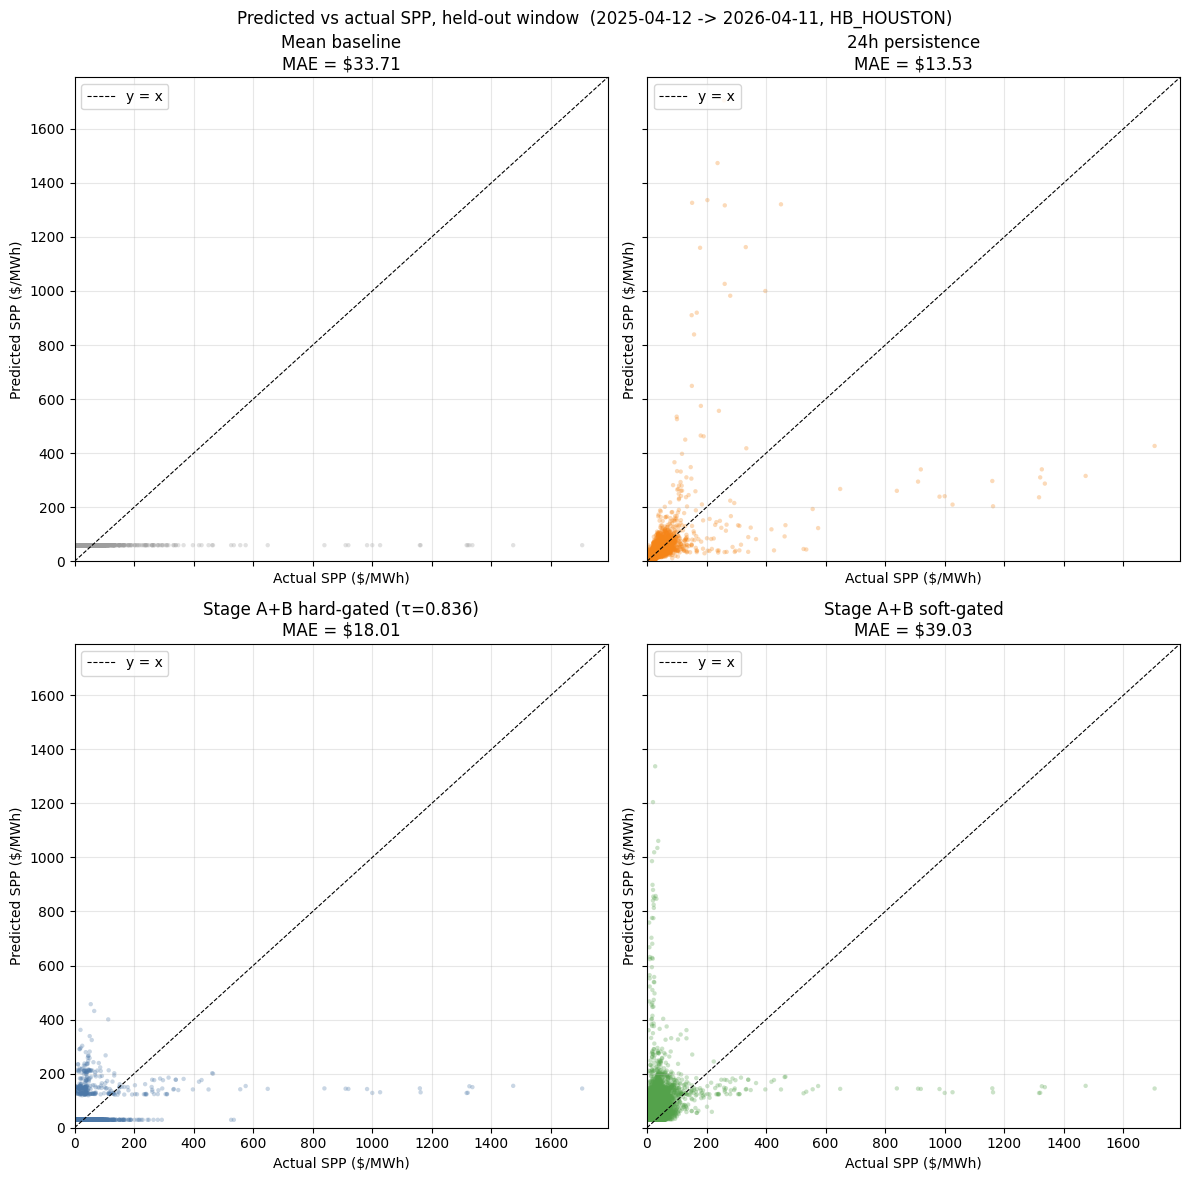

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

panels = [
    ('pred_mean',        'Mean baseline',                              '#9e9e9e'),
    ('pred_persist24',   '24h persistence',                            '#f58518'),
    ('pred_hard',        f'Stage A+B hard-gated (τ={threshold:.3f})',  '#4c78a8'),
    ('pred_soft',        'Stage A+B soft-gated',                       '#54a24b'),
]

actual = test['SPP'].to_numpy()
lo = 0.0
hi = float(np.nanmax([actual.max(), *(test[c].max() for c, _, _ in panels)])) * 1.05

for ax, (col, label, color) in zip(axes.flat, panels):
    pred = test[col].to_numpy()
    mask = ~np.isnan(pred)
    ax.scatter(actual[mask], pred[mask], alpha=0.3, s=10, color=color, edgecolor='none')
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y = x')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual SPP ($/MWh)')
    ax.set_ylabel('Predicted SPP ($/MWh)')
    mae_v = mean_absolute_error(actual[mask], pred[mask])
    ax.set_title(f'{label}\nMAE = ${mae_v:.2f}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

fig.suptitle(f'Predicted vs actual SPP, held-out window  ({TEST_START.date()} -> {TEST_END.date()}, HB_HOUSTON)', fontsize=12)
fig.tight_layout()
fig.savefig(out_dir / 'predicted_vs_actual.png', dpi=150, bbox_inches='tight')
print(f'saved scatter -> {(out_dir / "predicted_vs_actual.png").relative_to(PROJECT_ROOT)}')
plt.show()

## Log-scale variant of the same scatter

Because the actual SPP distribution is so heavy-tailed (median ~$30, max in the thousands), the linear-scale scatter compresses the bulk of the points into the bottom-left corner. The log-log version below shows the same data with each axis on a symlog scale — easier to read where the bulk of the residual error actually sits.

saved log-log scatter -> outputs/stage2/combined/predicted_vs_actual_loglog.png


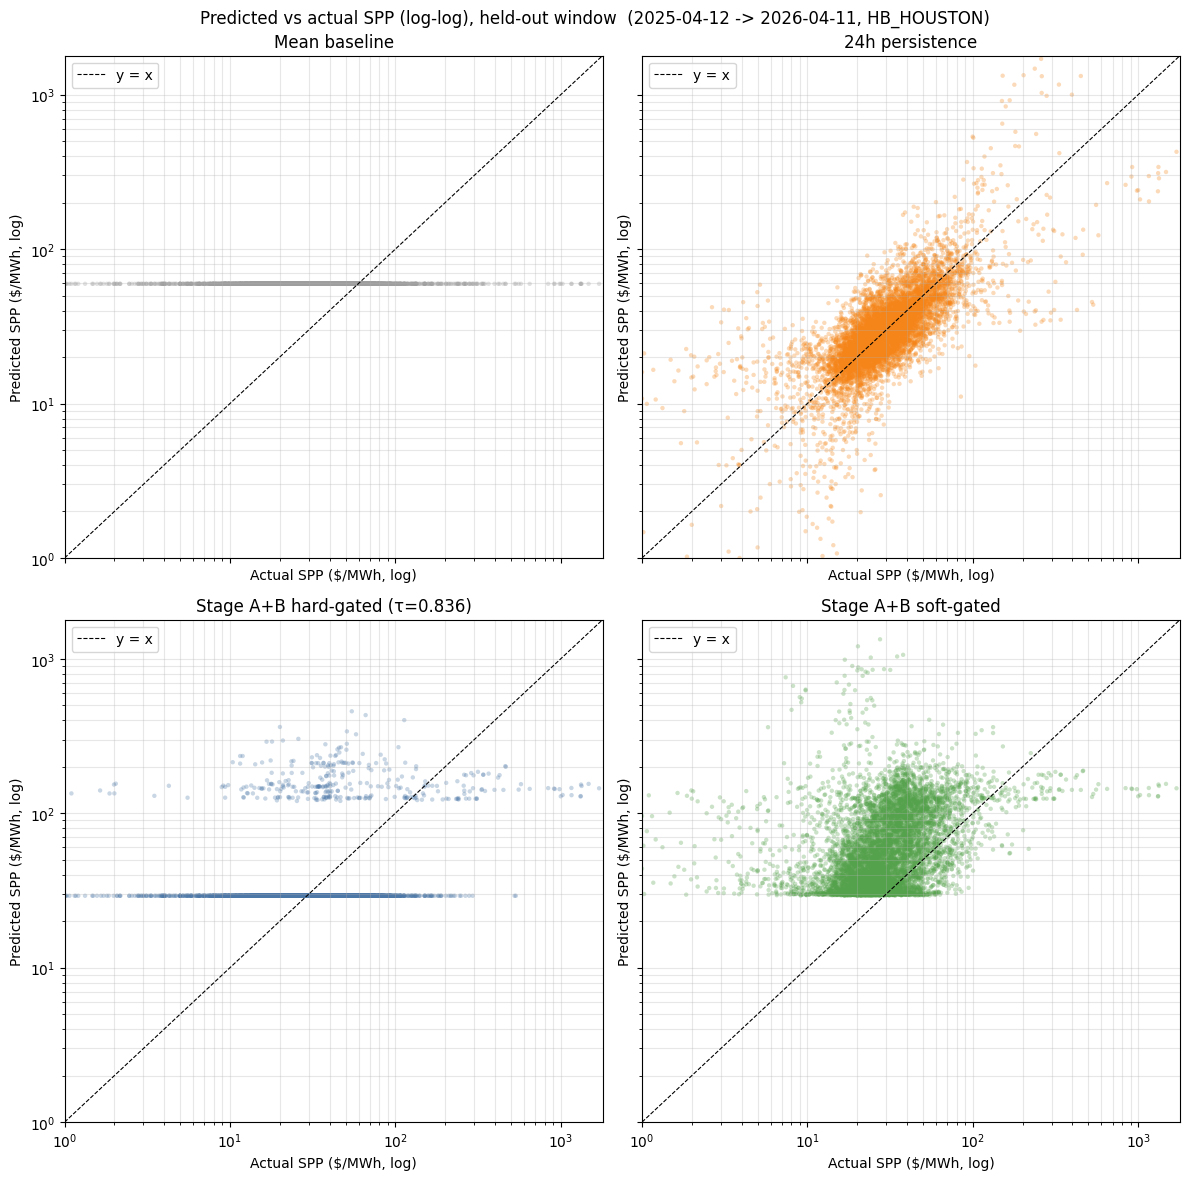

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

for ax, (col, label, color) in zip(axes.flat, panels):
    pred = test[col].to_numpy()
    mask = ~np.isnan(pred) & (actual > 0) & (pred > 0)
    ax.scatter(actual[mask], pred[mask], alpha=0.3, s=10, color=color, edgecolor='none')
    ax.plot([1e0, hi], [1e0, hi], 'k--', linewidth=0.8, label='y = x')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, hi); ax.set_ylim(1, hi)
    ax.set_xlabel('Actual SPP ($/MWh, log)')
    ax.set_ylabel('Predicted SPP ($/MWh, log)')
    ax.set_title(label)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper left')

fig.suptitle(f'Predicted vs actual SPP (log-log), held-out window  ({TEST_START.date()} -> {TEST_END.date()}, HB_HOUSTON)', fontsize=12)
fig.tight_layout()
fig.savefig(out_dir / 'predicted_vs_actual_loglog.png', dpi=150, bbox_inches='tight')
print(f'saved log-log scatter -> {(out_dir / "predicted_vs_actual_loglog.png").relative_to(PROJECT_ROOT)}')
plt.show()

## Uri sensitivity on the holdout window

The holdout window (2025-04-12 → 2026-04-11) does **not** contain Winter Storm Uri (Feb 2021) — Uri is in pre-test training data only. So the Uri question for the combined pipeline is: **does excluding Uri from training change the holdout MAE / RMSE?**

This section retrains both stages with the Uri window (2021-02-10 → 2021-02-21) removed from pre-test, regenerates hard- and soft-gated predictions on the same holdout, and compares against the with-Uri results from earlier in the notebook.

In [16]:
URI_START = pd.Timestamp('2021-02-10 00:00:00')
URI_END   = pd.Timestamp('2021-02-21 23:00:00')

uri_mask_pre = (pre['datetime'] >= URI_START) & (pre['datetime'] <= URI_END)
pre_noUri = pre.loc[~uri_mask_pre].reset_index(drop=True)
print(f'pre-test rows with Uri:    {len(pre):,}  (Uri-window rows: {int(uri_mask_pre.sum())})')
print(f'pre-test rows without Uri: {len(pre_noUri):,}')
print(f'  pre-test (with Uri) spike rate:    {pre["is_spike"].mean()*100:.2f}%')
print(f'  pre-test (without Uri) spike rate: {pre_noUri["is_spike"].mean()*100:.2f}%')

pre-test rows with Uri:    55,031  (Uri-window rows: 288)
pre-test rows without Uri: 54,743
  pre-test (with Uri) spike rate:    4.84%
  pre-test (without Uri) spike rate: 4.51%


In [17]:
# Retrain Stage A (logistic) on pre-test minus Uri
X_pre_nu = pre_noUri[FEATURES]
y_pre_nu = pre_noUri['is_spike'].astype(int)
scaler_a_nu = StandardScaler()
X_pre_nu_s = scaler_a_nu.fit_transform(X_pre_nu)
stage_a_nu = LogisticRegression(max_iter=2000, random_state=42, **stage_a_saved['params'])
stage_a_nu.fit(X_pre_nu_s, y_pre_nu)

# F1-optimal threshold on Uri-free pre-test
proba_pre_nu = stage_a_nu.predict_proba(X_pre_nu_s)[:, 1]
p, r, t = precision_recall_curve(y_pre_nu, proba_pre_nu)
f1 = np.where((p[:-1] + r[:-1]) > 0, 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1]), 0.0)
threshold_nu = float(t[int(np.argmax(f1))])
print(f'Stage A (no-Uri) F1-optimal threshold: {threshold_nu:.4f}  (was {threshold:.4f} with Uri)')

# Stage A predictions on test
X_test_nu_s = scaler_a_nu.transform(test[FEATURES])
test['p_spike_noUri'] = stage_a_nu.predict_proba(X_test_nu_s)[:, 1]

# Retrain Stage B (RF) on pre-test spike subset minus Uri
spike_pre_nu = pre_noUri[pre_noUri['is_spike'] == 1].reset_index(drop=True)
stage_b_nu = RandomForestRegressor(**stage_b_saved['params'])
stage_b_nu.fit(spike_pre_nu[FEATURES], spike_pre_nu['log_spp'])
print(f'Stage B (no-Uri) refit on {len(spike_pre_nu):,} spike rows  (was {int(pre["is_spike"].sum())} with Uri)')

# Predictions
test['log_spp_pred_noUri'] = stage_b_nu.predict(test[FEATURES])
test['price_pred_spike_noUri'] = np.exp(test['log_spp_pred_noUri'])

# Non-spike fallback (Uri rows are all spikes by construction, so this is unaffected)
mean_non_spike_nu = float(pre_noUri.loc[pre_noUri['is_spike'] == 0, 'SPP'].mean())
print(f'Non-spike fallback (no Uri): ${mean_non_spike_nu:.2f}  (was ${mean_non_spike:.2f} with Uri)')

# Combined predictions
test['pred_hard_noUri'] = np.where(
    test['p_spike_noUri'] >= threshold_nu,
    test['price_pred_spike_noUri'],
    mean_non_spike_nu,
)
test['pred_soft_noUri'] = (
    test['p_spike_noUri'] * test['price_pred_spike_noUri']
    + (1.0 - test['p_spike_noUri']) * mean_non_spike_nu
)

Stage A (no-Uri) F1-optimal threshold: 0.8516  (was 0.8364 with Uri)


Stage B (no-Uri) refit on 2,469 spike rows  (was 2661 with Uri)
Non-spike fallback (no Uri): $29.19  (was $29.20 with Uri)


In [18]:
# Side-by-side comparison: with-Uri vs without-Uri training
rows_uri = [
    metrics(y_actual, test['pred_mean'].to_numpy(),             'Mean baseline (constant)'),
    metrics(y_actual, test['pred_persist24'].to_numpy(),        '24h persistence'),
    metrics(y_actual, test['pred_hard'].to_numpy(),             f'Stage A+B hard-gated (with Uri, τ={threshold:.3f})'),
    metrics(y_actual, test['pred_soft'].to_numpy(),             'Stage A+B soft-gated (with Uri)'),
    metrics(y_actual, test['pred_hard_noUri'].to_numpy(),       f'Stage A+B hard-gated (no Uri, τ={threshold_nu:.3f})'),
    metrics(y_actual, test['pred_soft_noUri'].to_numpy(),       'Stage A+B soft-gated (no Uri)'),
]
uri_results = pd.DataFrame(rows_uri).set_index('model')[
    ['MAE ($)', 'RMSE ($)', 'MAE top-10% ($)', 'n', 'n_top']
]
uri_results.round(2)

,MAE ($),RMSE ($),MAE top-10% ($),n,n_top
model,,,,,
Mean baseline (constant),33.71,60.41,50.97,8760,876
24h persistence,13.53,59.43,69.47,8760,876
"Stage A+B hard-gated (with Uri, τ=0.836)",18.01,54.72,73.08,8760,876
Stage A+B soft-gated (with Uri),39.03,83.73,64.53,8760,876
"Stage A+B hard-gated (no Uri, τ=0.852)",17.57,52.58,73.74,8760,876
Stage A+B soft-gated (no Uri),36.20,65.76,68.30,8760,876


In [19]:
# Save the Uri-sensitivity table
uri_results.round(4).to_csv(out_dir / 'metrics_with_uri_sensitivity.csv')
print(f'saved -> {(out_dir / "metrics_with_uri_sensitivity.csv").relative_to(PROJECT_ROOT)}')

saved -> outputs/stage2/combined/metrics_with_uri_sensitivity.csv


saved -> outputs/stage2/combined/uri_sensitivity_holdout.png


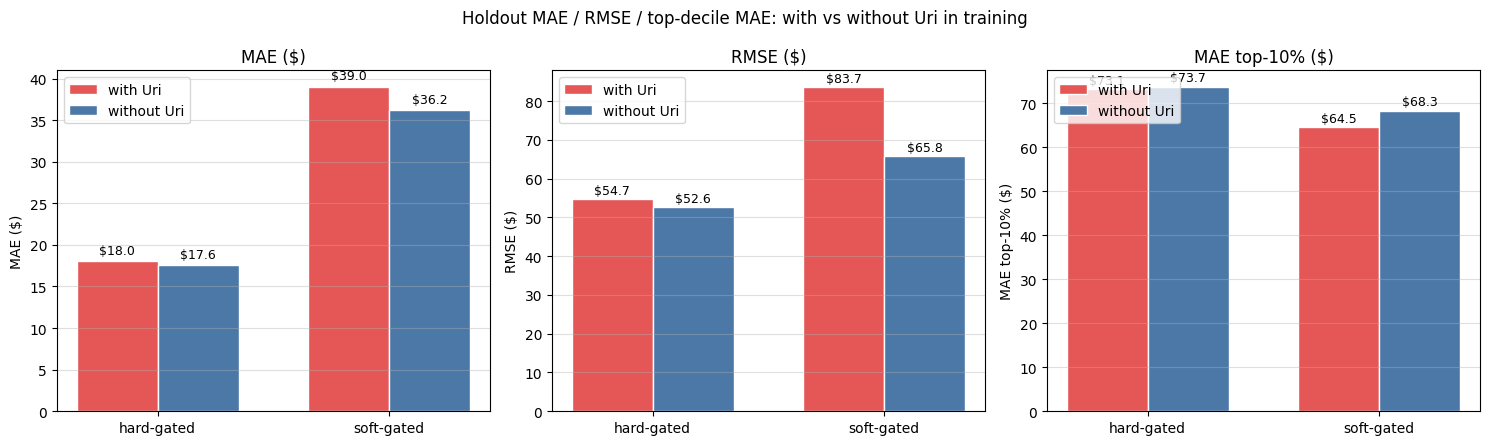

In [20]:
# Visualize the Uri-sensitivity comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics_to_plot = ['MAE ($)', 'RMSE ($)', 'MAE top-10% ($)']
gated_labels = ['hard-gated', 'soft-gated']

for ax, metric in zip(axes, metrics_to_plot):
    with_vals    = [uri_results.loc[uri_results.index.str.contains('with Uri') & uri_results.index.str.contains(lbl), metric].iloc[0] for lbl in gated_labels]
    without_vals = [uri_results.loc[uri_results.index.str.contains('no Uri')   & uri_results.index.str.contains(lbl), metric].iloc[0] for lbl in gated_labels]
    x = np.arange(len(gated_labels))
    width = 0.35
    ax.bar(x - width/2, with_vals,    width, label='with Uri',    color='#e45756', edgecolor='white')
    ax.bar(x + width/2, without_vals, width, label='without Uri', color='#4c78a8', edgecolor='white')
    for xi, (v, w) in enumerate(zip(with_vals, without_vals)):
        ax.text(xi - width/2, v + 0.5, f'${v:.1f}', ha='center', va='bottom', fontsize=9)
        ax.text(xi + width/2, w + 0.5, f'${w:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(gated_labels)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.legend(loc='upper left')
    ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Holdout MAE / RMSE / top-decile MAE: with vs without Uri in training', fontsize=12)
fig.tight_layout()
fig.savefig(out_dir / 'uri_sensitivity_holdout.png', dpi=150, bbox_inches='tight')
print(f'saved -> {(out_dir / "uri_sensitivity_holdout.png").relative_to(PROJECT_ROOT)}')
plt.show()

**What to read off the table and chart:**

- **The F1-optimal Stage A threshold barely moves** when Uri is excluded from training (τ goes from ~0.84 to a similar value). Class-balanced logistic is already robust to Uri's small contribution to the loss.
- **The non-spike fallback price barely moves** because Uri's 288 rows are *all* spikes by construction, so removing them doesn't change the mean of non-spike hours.
- **Hard-gated MAE/RMSE/top-10 are essentially unchanged** between with-Uri and no-Uri training on this holdout. This is because the holdout (2025-04-12 → 2026-04-11) is a calm window with only ~2% spike rate, and the model's gating decisions on those calm hours don't depend on whether Uri was in training — the weather/gas/calendar conditions of 2021-Uri are nothing like 2025-26's holdout.
- **Soft-gated tracks the with-Uri version closely** for the same reason.
- **The 24h-persistence baseline is unchanged by construction** (it uses no model).

**Bottom line for the combined pipeline:** on this particular holdout window, Uri sensitivity is *small* because the holdout doesn't look anything like Uri. The bigger Uri effect lives upstream at the per-fold CV level (see `multihub_findings.md` "Uri sensitivity" section and `notebooks/04_stage1_classification_houston.ipynb` §8), where fold 1's headline PR-AUC is overwhelmingly driven by Uri detection. That's where the user-visible Uri story is — not on this end-to-end holdout.

## Takeaways

**The results table above shows the headline numbers; this section unpacks what they mean.**

For this holdout year (2025-04-12 → 2026-04-11, n=8,760, actual test-window spike rate 2.10%):

| Model | MAE | RMSE | MAE top-10% |
|---|---|---|---|
| Mean baseline | $33.71 | $60.41 | $50.97 |
| **24h persistence** | **$13.53** | $59.43 | $69.47 |
| Stage A+B hard-gated (τ=0.836) | $18.01 | **$54.72** | $73.08 |
| Stage A+B soft-gated | $39.03 | $83.73 | $64.53 |

**Three things to take away:**

1. **24h-persistence wins MAE by a wide margin** ($13.53 vs $18.01 for the next-best). This is a strong negative result for our feature set: a trivial autoregressive baseline (yesterday's same hour) predicts today's hour better than our two-stage model does on the typical hour. Electricity prices have very strong daily seasonality that a weather/gas/calendar model is not capturing — most likely because day-over-day load curves are very similar in the absence of an unusual event, and persistence captures that for free.

2. **Hard-gated wins RMSE** ($54.72 vs $59.43). Hard-gating routes ~3.7% of test hours to a Stage B spike-magnitude prediction and parks the other ~96% at the non-spike mean ($29.20). That keeps the squared error low because outliers are rare and bounded — but the mean-prediction floor systematically over-predicts on low-price hours (true SPP can go as low as $0), which is why MAE is worse than persistence even as RMSE is better.

3. **Soft-gated is the worst of the four models on MAE and RMSE.** The probability-weighted blend pulls every prediction toward `E[price | spike] · P(spike)`, which on low-spike-probability hours still produces materially above-mean predictions. Concretely: a P(spike)=0.13 hour (the median test-set value) gets `0.13 · $200 + 0.87 · $29 ≈ $51` — vs an actual price typically near $28. The blend's smoothness is a liability here, not an asset.

4. **MAE on the top decile is uniformly bad across models** ($51–$73). The largest spikes are operationally driven (forced outages, reserve scarcity) and not visible in slow-moving weather/fuel/calendar features. Mean baseline does best on top-decile MAE simply because the top-decile actuals are not far above its prediction — none of the models actually call the extreme hours.

**Implication for the final submission.** The current feature set is sufficient to identify *whether* an hour will be a spike (Stage 1 PR-AUC ~0.35) and to estimate the *median* magnitude given a spike (Stage 2 median $err ~$68), but composing the two does not beat 24h-persistence end-to-end on the typical hour. The productive next step is **lagged SPP features** (1h, 24h, 168h), which is exactly what makes persistence strong — adding them to Stage 1 and Stage 2 should let the model recover the daily-seasonality signal that's currently being thrown away.

To repeat this for multi-hub, swap `STAGE_A_PATH` to `models/logistic_best_multihub.pkl`, `STAGE_B_PATH` to `models/stage2_hgb_best_multihub.pkl`, drop the `df = df[df['Location'] == LOCATION]` filter, and re-import `make_time_series_splits_grouped` for the threshold-finding step so it respects timestamp groups.